In [67]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, mean_absolute_error


In [68]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# --------------------------
# 前処理関数
# --------------------------
def preprocess_single_rssi(df, rssi_col, window=5):
    X = pd.DataFrame()
    df = df.bfill()
    X["rssi"] = df[rssi_col]
    X["rssi_ma"] = df[rssi_col].rolling(window, min_periods=1).mean()
    X["rssi_diff"] = df[rssi_col].diff().fillna(0)
    return X

# --------------------------
# 疑似負例生成
# --------------------------
def generate_negative_examples(X_pos, scale=30):
    X_neg = X_pos.copy()
    X_neg["rssi"] = X_neg["rssi"] - np.random.randint(scale//2, scale, size=len(X_neg))
    X_neg["rssi"] = X_neg["rssi"].clip(lower=0)
    # 移動平均と差分も再計算
    X_neg["rssi_ma"] = X_neg["rssi"].rolling(5, min_periods=1).mean()
    X_neg["rssi_diff"] = X_neg["rssi"].diff().fillna(0)
    return X_neg

# --------------------------
# ラベル作成
# --------------------------
def make_labels(X_pos, X_neg):
    y_pos = np.ones(len(X_pos))
    y_neg = np.zeros(len(X_neg))
    return np.concatenate([y_pos, y_neg])

# --------------------------
# モデル学習＆可視化関数
# --------------------------
def train_and_plot_beacon(df, rssi_col, scale=30):
    # 正例
    X_pos = preprocess_single_rssi(df, rssi_col)
    # 疑似負例
    X_neg = generate_negative_examples(X_pos, scale=scale)
    # データ結合
    X_train = pd.concat([X_pos, X_neg]).reset_index(drop=True)
    y_train = make_labels(X_pos, X_neg)
    
    # モデル学習
    model = LogisticRegression(class_weight="balanced", max_iter=1000)
    model.fit(X_train, y_train)
    
    # Sigmoid出力
    p_pred = model.predict_proba(X_train)[:,1]
    auc = roc_auc_score(y_train, p_pred)
    print(f"{rssi_col} Train AUC: {auc:.4f}")
    
    # 可視化
    plt.figure(figsize=(10,4))
    plt.plot(p_pred, label="Sigmoid output")
    plt.plot(y_train, alpha=0.3, label="True label")
    plt.title(f"Sigmoid output vs True label ({rssi_col})")
    plt.legend()
    plt.show()
    
    return model


=== Training 0 ===
810B3B76 Train AUC: 0.9736


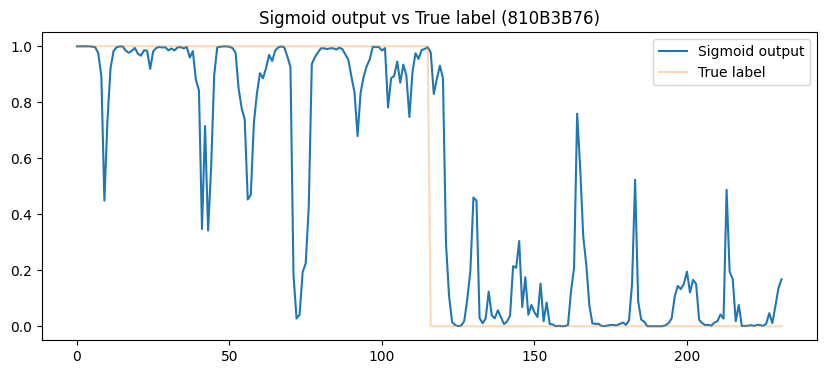

=== Training 1 ===
81025B89 Train AUC: 0.9682


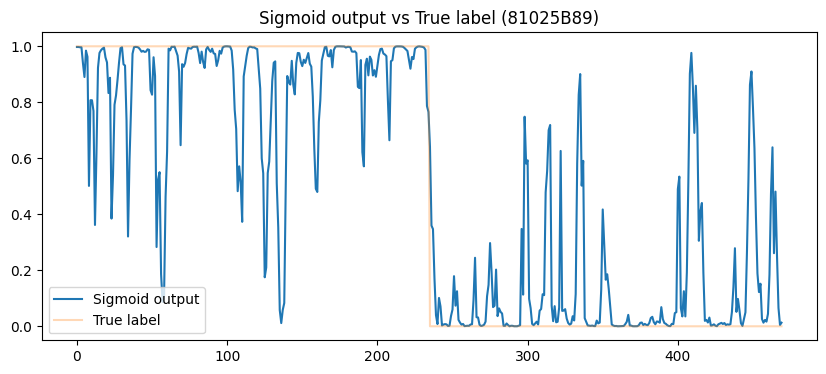

=== Training 2 ===
81025919 Train AUC: 0.9595


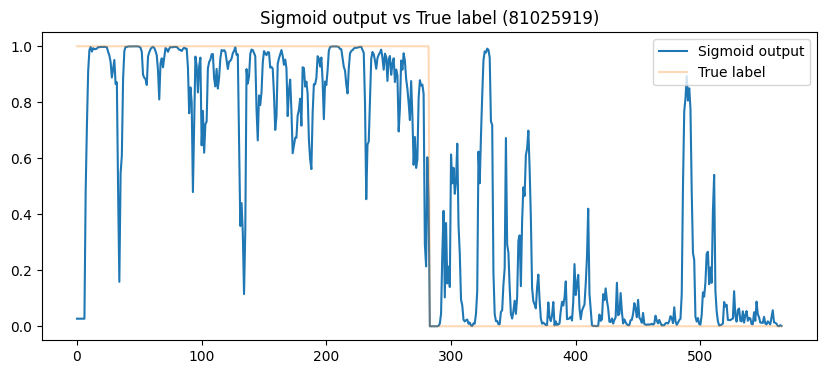

=== Training 3 ===
810257F7 Train AUC: 0.9497


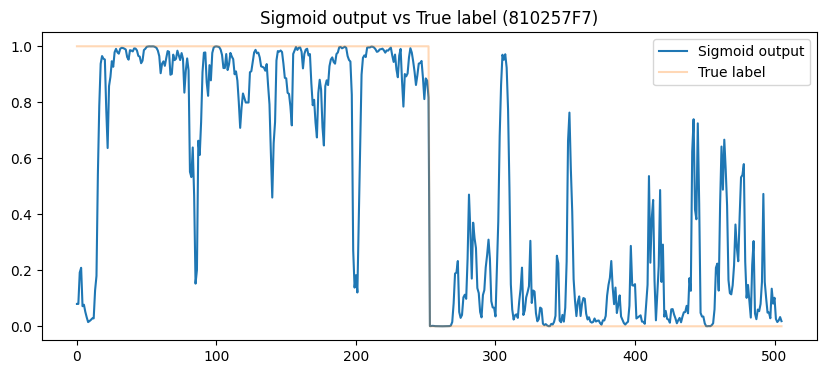

In [69]:
beacon_cols = {0:"810B3B76",1:"81025B89",2:"81025919",3:"810257F7"}

models = {}

for num,col in beacon_cols.items():
    print(f"=== Training {num} ===")
    df = pd.read_csv(f"../../../../実験/train_beacon/beacon{num}.csv")
    models[num] = train_and_plot_beacon(df, col, scale=40)


# HMM

In [70]:
# --- 状態遷移行列作成 ---
def make_transition_matrix(n_classes=7):
    A = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in [i-1, i, i+1]:
            if 0 <= j < n_classes:
                A[i,j] = 1.0
        A[i] /= A[i].sum()
    return A

A = make_transition_matrix()

# --- 特徴選択関数 ---
def select_features(df, way="all"):
    if way == "all":
        cols_to_drop = [c for c in df.columns if "time" in c.lower()]
        return df.drop(columns=cols_to_drop, errors="ignore")
    elif way == "rssi":
        return df[["810257F7","81025919","81025B89","810B3B76"]]
    else:
        raise ValueError("way must be 'all' or 'rssi'")

# --- Forward-only HMM 推定関数 ---
def forward_hmm_predict_and_eval(sigmoid_probs, y_true, A):
    n_classes = A.shape[0]
    n_samples = sigmoid_probs.shape[0]
    
    class_map = {0:0, 1:1, 2:3, 3:5}  # ビーコン→クラス対応
    alpha = np.ones(n_classes) / n_classes
    predicted_classes = []

    for t in range(n_samples):
        O_t = np.ones(n_classes) * 0.01
        for c in class_map.values():
            b_idx = list(class_map.keys())[list(class_map.values()).index(c)]
            O_t[c] = sigmoid_probs[t, b_idx]
        alpha = O_t * (alpha @ A)
        alpha /= alpha.sum()
        predicted_classes.append(np.argmax(alpha))
    
    predicted_classes = np.array(predicted_classes)
    
    acc = accuracy_score(y_true, predicted_classes)
    tol_acc = np.mean(np.abs(y_true - predicted_classes) <= 1)
    mae = mean_absolute_error(y_true, predicted_classes)
    
    print(f"Forward-only HMM accuracy: {acc:.4f}")
    print(f"Forward-only HMM tolerance accuracy (±1): {tol_acc:.4f}, MAE: {mae:.2f}")
    
    plt.figure(figsize=(12,4))
    plt.plot(y_true, label="True class", alpha=0.7)
    plt.plot(predicted_classes, label="Predicted class (Forward HMM)", alpha=0.8)
    plt.xlabel("Time step")
    plt.ylabel("Class")
    plt.title("Forward-only HMM Class Estimation")
    plt.legend()
    plt.show()
    
    return predicted_classes

# --- テストデータロード ---
keyword_B = "tuji2"
df = pd.read_csv(f"../../../../実験/label_beacon/{keyword_B}_beacon_label_0~6.csv")
dfB_label = df[['beacon_label']].copy()
dfB_feat  = df.drop(columns=['beacon_label'], errors='ignore')

# --- beacon_cols に基づき変数を選択して前処理 ---
X_test = pd.DataFrame()
for i, col in beacon_cols.items():
    # preprocess_single_rssi で出力列を固定
    X_proc = preprocess_single_rssi(dfB_feat,col)
    # 列名を rssi, rssi_diff, rssi_ma に固定
    X_proc.columns = [f"rssi_{i}", f"rssi_diff_{i}", f"rssi_ma_{i}"]
    # 4つのビーコンの特徴を連結
    X_test = pd.concat([X_test, X_proc], axis=1)

y_test = dfB_label["beacon_label"].reset_index(drop=True)

# --- Sigmoid予測用配列 ---
sigmoid_probs = np.zeros((len(X_test), 4))

for i, col in beacon_cols.items():
    model = models[i]
    
    # 訓練時の列名を取得
    feat_names = model.feature_names_in_
    
    # X_test に列が足りない場合は 0 で埋める
    for f in feat_names:
        if f not in X_test.columns:
            X_test[f] = 0.0
    
    # 訓練時と同じ列順に揃える
    X_input = X_test[feat_names]
    
    # 予測確率を取得
    prob = model.predict_proba(X_input)
    sigmoid_probs[:, i] = prob[:, 1]


Classifier only accuracy: 0.1341
Classifier only tolerance accuracy (±1): 0.2276, MAE: 2.86
Forward-only HMM accuracy: 0.0285
Forward-only HMM tolerance accuracy (±1): 0.1626, MAE: 3.78


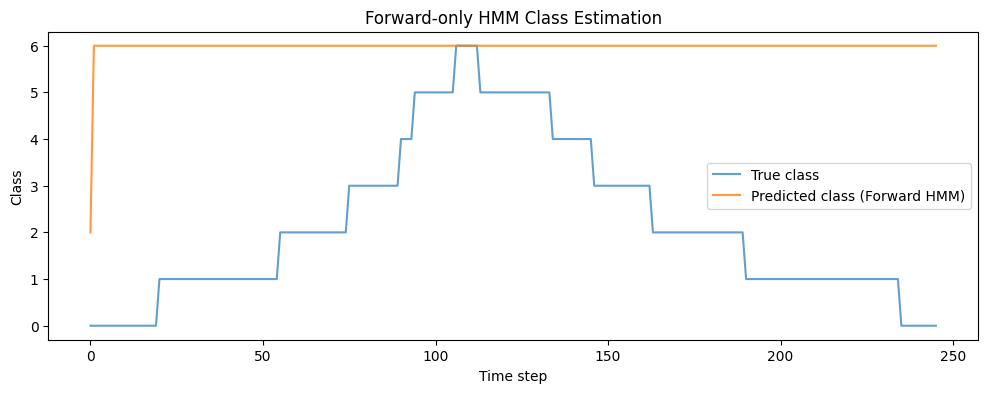

Forward-only HMM accuracy: 0.0285
Forward-only HMM tolerance accuracy (±1): 0.1626, MAE: 3.78


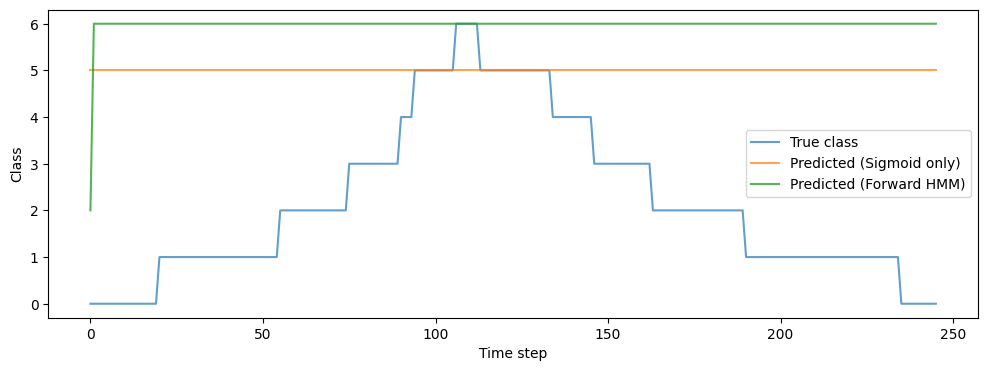

In [71]:
# ビーコン番号 → 7クラスの位置
class_map = {0: 0, 1: 1, 2: 3, 3: 5}  # 0番ビーコンはクラス0, 1番はクラス1, 2番はクラス3, 3番はクラス5


# --- HMM前の分類精度（Sigmoid だけ） ---
# 各ビーコンモデルの予測確率を7クラスにマッピングして一番高いものを選ぶ
# class_map = {0:0, 1:1, 2:3, 3:5}  # 既存のマッピング
sigmoid_pred_classes = np.zeros(len(y_test), dtype=int)

for t in range(len(y_test)):
    # 各ビーコンの正例確率をクラス位置に割り当て
    votes = np.zeros(7)
    for b_idx, cls in enumerate(class_map.values()):
        votes[cls] = sigmoid_probs[t, b_idx]
    sigmoid_pred_classes[t] = np.argmax(votes)

# --- 精度計算（HMM前） ---
acc_pre = accuracy_score(y_test, sigmoid_pred_classes)
tol_acc_pre = np.mean(np.abs(y_test - sigmoid_pred_classes) <= 1)
mae_pre = mean_absolute_error(y_test, sigmoid_pred_classes)

print(f"Classifier only accuracy: {acc_pre:.4f}")
print(f"Classifier only tolerance accuracy (±1): {tol_acc_pre:.4f}, MAE: {mae_pre:.2f}")

# --- Forward-only HMM 推定 ---
pred_classes = forward_hmm_predict_and_eval(sigmoid_probs, y_test.values, A)

# --- HMM後の精度計算 ---
acc_post = accuracy_score(y_test, pred_classes)
tol_acc_post = np.mean(np.abs(y_test - pred_classes) <= 1)
mae_post = mean_absolute_error(y_test, pred_classes)

print(f"Forward-only HMM accuracy: {acc_post:.4f}")
print(f"Forward-only HMM tolerance accuracy (±1): {tol_acc_post:.4f}, MAE: {mae_post:.2f}")

# --- 両者比較グラフ ---
plt.figure(figsize=(12,4))
plt.plot(y_test, label="True class", alpha=0.7)
plt.plot(sigmoid_pred_classes, label="Predicted (Sigmoid only)", alpha=0.7)
plt.plot(pred_classes, label="Predicted (Forward HMM)", alpha=0.8)
plt.xlabel("Time step")
plt.ylabel("Class")
plt.legend()
plt.show()


Train AUC (beacon 810B3B76): 0.9983
Train AUC (beacon 81025B89): 0.9965
Train AUC (beacon 81025919): 0.9983
Train AUC (beacon 810257F7): 0.9970
Forward-only HMM accuracy: 0.3252
Forward-only HMM tolerance accuracy (±1): 0.6423, MAE: 1.45


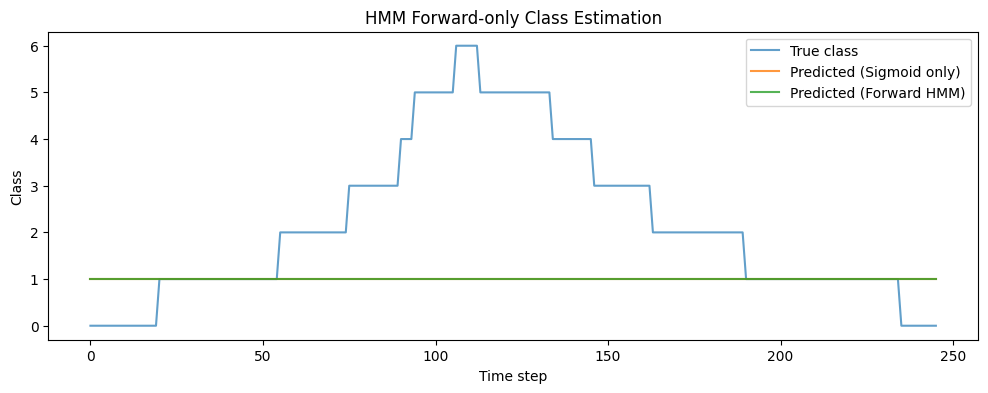

In [72]:
# --- 疑似負例作成付きモデル学習 ---
def train_beacon_with_neg(df, col, scale=40):
    X_pos = preprocess_single_rssi(df,col)
    X_pos.columns = ["rssi", "rssi_diff", "rssi_ma"]
    y_pos = np.ones(len(X_pos))

    # 疑似負例：rssiを平均より少し下にずらす
    X_neg = X_pos.copy()
    X_neg["rssi"] = X_neg["rssi"] - scale
    y_neg = np.zeros(len(X_neg))

    X_train = pd.concat([X_pos, X_neg], axis=0).reset_index(drop=True)
    y_train = np.concatenate([y_pos, y_neg])

    model = LogisticRegression(solver="liblinear")
    model.fit(X_train, y_train)

    # 訓練データの予測確認
    prob_train = model.predict_proba(X_train)[:, 1]
    auc_train = roc_auc_score(y_train, prob_train)
    print(f"Train AUC (beacon {col}): {auc_train:.4f}")
    return model

# --- 4ビーコンモデル作成 ---
models = {}
for i, col in beacon_cols.items():
    df_train = pd.read_csv(f"../../../../実験/train_beacon/beacon{i}.csv")
    models[i] = train_beacon_with_neg(df_train, col)

# --- テストデータ前処理 ---
X_test = pd.DataFrame()
for i, col in beacon_cols.items():
    X_proc = preprocess_single_rssi(dfB_feat,col)
    X_proc.columns = [f"rssi_{i}",f"rssi_diff_{i}", f"rssi_ma_{i}"]
    X_test = pd.concat([X_test, X_proc], axis=1)

# --- Sigmoid予測 ---
sigmoid_probs = np.zeros((len(X_test), 4))
for i, col in beacon_cols.items():
    model = models[i]
    # 欠損列補完
    for f in model.feature_names_in_:
        if f not in X_test.columns:
            X_test[f] = 0.0
    X_input = X_test[model.feature_names_in_]
    sigmoid_probs[:, i] = model.predict_proba(X_input)[:, 1]

# --- Forward-only HMM 推定（初期 α 補正） ---
def forward_hmm_predict_and_eval_fix(sigmoid_probs, y_true, A, start_class=0):
    n_classes = A.shape[0]
    n_samples = sigmoid_probs.shape[0]
    class_map = {0:0, 1:1, 2:3, 3:5}
    
    alpha = np.zeros(n_classes)
    alpha[start_class] = 1.0  # 初期値を最初のクラスに寄せる
    predicted_classes = []

    for t in range(n_samples):
        O_t = np.ones(n_classes) * 0.001
        for c in class_map.values():
            b_idx = list(class_map.keys())[list(class_map.values()).index(c)]
            O_t[c] = sigmoid_probs[t, b_idx]
        alpha = O_t * (alpha @ A)
        alpha /= alpha.sum()
        predicted_classes.append(np.argmax(alpha))

    predicted_classes = np.array(predicted_classes)
    
    # --- 評価 ---
    acc = accuracy_score(y_true, predicted_classes)
    tol_acc = np.mean(np.abs(y_true - predicted_classes) <= 1)
    mae = mean_absolute_error(y_true, predicted_classes)
    print(f"Forward-only HMM accuracy: {acc:.4f}")
    print(f"Forward-only HMM tolerance accuracy (±1): {tol_acc:.4f}, MAE: {mae:.2f}")

    # --- 可視化 ---
    plt.figure(figsize=(12,4))
    plt.plot(y_true, label="True class", alpha=0.7)
    plt.plot(np.argmax(sigmoid_probs, axis=1), label="Predicted (Sigmoid only)", alpha=0.8)
    plt.plot(predicted_classes, label="Predicted (Forward HMM)", alpha=0.8)
    plt.xlabel("Time step")
    plt.ylabel("Class")
    plt.title("HMM Forward-only Class Estimation")
    plt.legend()
    plt.show()
    return predicted_classes

# --- 推定 ---
pred_classes = forward_hmm_predict_and_eval_fix(sigmoid_probs, y_test.values, A, start_class=0)


Template accuracy: 0.1260
Template tolerance accuracy (±1): 0.4512, MAE: 2.20


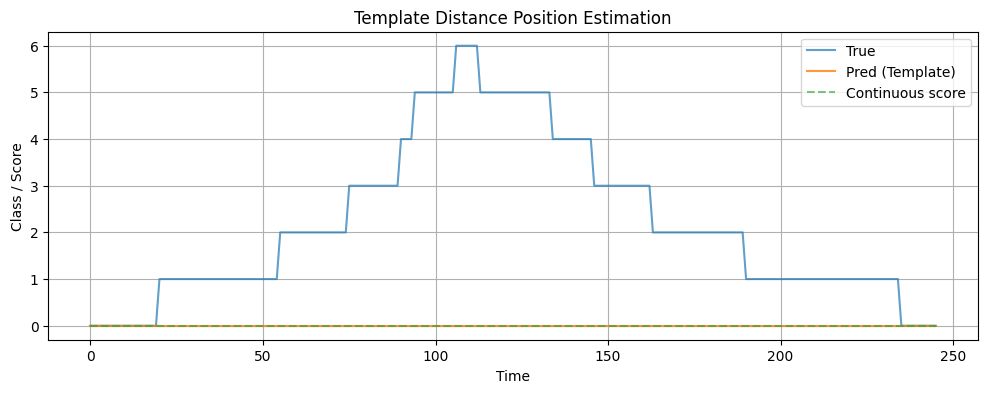

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
beacon_cols = {
    0: "810B3B76",
    1: "81025B89",
    2: "81025919",
    3: "810257F7"
}

# ビーコン → 7クラス空間での代表位置
beacon_to_class = {
    0: 0,
    1: 1,
    2: 3,
    3: 5
}

EPS = 1e-6

# =========================
# 1. テンプレート作成
# =========================
def build_templates():
    templates = {}
    for i, col in beacon_cols.items():
        df = pd.read_csv(f"../../../../実験/train_beacon/beacon{i}.csv")
        rssi = df[col].values.astype(float)
        templates[i] = {
            "mean": np.mean(rssi),
            "std":  np.std(rssi) + EPS
        }
    return templates

templates = build_templates()

# =========================
# 2. 距離 → スコア変換
# =========================
def rssi_distance(x, mean, std):
    return np.abs(x - mean) / std

def distance_to_score(d):
    return 1.0 / (d + 1.0)

# =========================
# 3. 推定（リアルタイム対応）
# =========================
def template_position_estimate(df_test):
    cont_score = []
    pred_class = []

    prev_class = None

    for t in range(len(df_test)):
        scores = {}

        for i, col in beacon_cols.items():
            x = df_test.iloc[t][col]

            if np.isnan(x):
                continue  # RSSI欠損は無視

            # テンプレートに有効な統計値がないビーコンは無視
            if np.isnan(templates[i]["mean"]) or np.isnan(templates[i]["std"]):
                continue

            d = rssi_distance(x, templates[i]["mean"], templates[i]["std"])
            scores[i] = distance_to_score(d)

    # 有効ビーコンが1つも無い場合
        if len(scores) == 0:
            if prev_class is not None:
                cont_score.append(prev_class)
                pred_class.append(prev_class)
                continue
            else:
                cont_score.append(3.0)  # 中央に落とす
                pred_class.append(3)
                prev_class = 3
                continue

        # 連続位置スコア（重み付き平均）
        num = sum(scores[i] * beacon_to_class[i] for i in scores)
        den = sum(scores.values()) + EPS
        pos = num / den
        cont_score.append(pos)

        # 離散化（移動制約）
        c = int(round(pos))
        c = max(0, min(6, c))

        if prev_class is not None:
            if abs(c - prev_class) > 1:
                c = prev_class + np.sign(c - prev_class)

        pred_class.append(c)
        prev_class = c

    return np.array(pred_class), np.array(cont_score)

# =========================
# 4. テストデータ読み込み
# =========================
keyword_B = "tuji2"
df = pd.read_csv(f"../../../../実験/label_beacon/{keyword_B}_beacon_label_0~6.csv")

y_true = df["beacon_label"].values
df_test = df[list(beacon_cols.values())]

# =========================
# 5. 推定 & 評価
# =========================
pred, cont = template_position_estimate(df_test)

acc = np.mean(pred == y_true)
tol_acc = np.mean(np.abs(pred - y_true) <= 1)
mae = np.mean(np.abs(pred - y_true))

print(f"Template accuracy: {acc:.4f}")
print(f"Template tolerance accuracy (±1): {tol_acc:.4f}, MAE: {mae:.2f}")

# =========================
# 6. 可視化
# =========================
plt.figure(figsize=(12,4))
plt.plot(y_true, label="True", alpha=0.7)
plt.plot(pred, label="Pred (Template)", alpha=0.8)
plt.plot(cont, "--", label="Continuous score", alpha=0.6)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Class / Score")
plt.title("Template Distance Position Estimation")
plt.grid(True)
plt.show()
